# EDA y reducción de features  Bajo Peso al Nacer (LBW), Perú
**Dataset:** Certificado de Nacido Vivo (CNV) – MINSA, corte 30/11/2025 (nacimientos 2015–2025)
**Target:** `PESO_NACIDO` (g) → regresión · `LBW = 1 si peso < 2500 g` (definición OMS) → clasificación
**Papers de referencia:**
- Khan et al. (2022), *Scientific Reports* 12:12110 — UAE, 821 madres, LR + SMOTE, features clave: edad gestacional, diabetes, hipertensión.
- Almeida et al. (2026), *São Paulo Med J* 144(3) — SINASC Brasil (registro de nacidos vivos, **muy parecido al CNV**), 2.5 M registros, LR balanceada (recall 0.69, AUC 0.85).

**Estructura**
1. Carga y corrección del archivo
2. Vista general y calidad de datos (códigos "IGNORADO", `-1`, valores imposibles)
3. Análisis del target
4. Limpieza y construcción de variables
5. Análisis univariado
6. Análisis bivariado vs LBW (+ pruebas estadísticas)
7. Correlación / redundancia entre features
8. Reducción de features (filtros + relevancia: Cramér's V, información mutua, importancia por permutación)
9. Conclusiones y dataset final

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
warnings.filterwarnings("ignore")


# ---------------- DATOS: descarga desde el repositorio del proyecto ----------------
import zipfile, requests

URL_ZIP   = "https://raw.githubusercontent.com/jasnai10/AI_Project/main/proyecto/data/raw/dataset.zip"  # fuente del dataset
ZIP_PATH  = "data/dataset.zip"                                     # copia local del zip
FIXED_CSV = "data/cnv_fixed.csv"                                   # se genera automáticamente
os.makedirs("data", exist_ok=True)                                 # crea la carpeta si no existe

if not os.path.exists(ZIP_PATH):                                   # descarga solo la primera vez
    r = requests.get(URL_ZIP); r.raise_for_status()                # falla con mensaje claro si la URL no responde
    open(ZIP_PATH, "wb").write(r.content)

with zipfile.ZipFile(ZIP_PATH) as z:                               # extrae el CSV original del zip
    nombre = z.namelist()[0]
    assert nombre.endswith(".csv"), f"Contenido inesperado en el zip: {nombre}"
    RAW_CSV = os.path.join("data", nombre)
    if not os.path.exists(RAW_CSV):
        z.extract(nombre, "data")

print("CSV original:", RAW_CSV)

FIG_DIR   = "eda_figuras"
os.makedirs(FIG_DIR, exist_ok=True)
SEED = 42

# Estilo de gráficos: ejes y grilla discretos, marcas delgadas
NORMAL, LBW_C, SEQ = "#2a78d6", "#eb6834", "#2a78d6"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "axes.titleweight": "bold", "axes.titlesize": 11, "font.size": 9.5,
})
def savefig(name):
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight"); plt.show()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

CSV original: data/CNV_MINSA_CORTE_30112025.csv


## 1. Carga y corrección del archivo
El CSV usa `;` como separador, pero **388 filas** tienen un `;` dentro de `DESC_OCUPACION`
(ej. `VENDEDOR AMBULANTE; COSMETICOS, PERFUMES...`), lo que genera 23 columnas en vez de 22.
Se corrige uniendo los fragmentos de ocupación antes de cargar.

In [ ]:
N_COLS = 22
if not os.path.exists(FIXED_CSV):
    n_fix = 0
    with open(RAW_CSV, encoding="utf-8") as f, open(FIXED_CSV, "w", encoding="utf-8") as o:
        for line in f:
            p = line.rstrip("\r\n").split(";")
            if len(p) > N_COLS:                       # ocupación con ';' adentro
                k = len(p) - N_COLS
                p = p[:11] + [",".join(p[11:12 + k])] + p[12 + k:]
                n_fix += 1
            o.write(";".join(x.strip() for x in p) + "\n")
    print("Filas corregidas:", n_fix)

raw = pd.read_csv(FIXED_CSV, sep=";", dtype="category", keep_default_na=False)
print("Shape:", raw.shape)
raw.head()

Filas corregidas: 388
Shape: (4874510, 22)


,FecNac_Año,FecNac_Mes,PESO_NACIDO,TALLA_NACIDO,DUR_EMB_PARTO,Condicion_Parto,sexo_nacido,Tipo_Parto,Edad_Madre,Estado_Civil,Nivel_Intrucción_Madre,DESC_OCUPACION,Num_embar_madre,Hijos_vivo_madre,Hijos_fallec_madre,nacmuer_abort_madre,Pais_Madre,IdUbigeoInei,Ipress,Lugar_Nacido,Atiende_Parto,Financiador_Parto
0,2021,08,3620,52,40,EUTOCICO,MASCULINO,UNICO,34,SOLTERO,SECUNDARIA COMPLETA,AMA DE CASA,3,2,-1,1,PERU,150121,6211,ESTABLECIMIENTO DE SALUD,OBSTETRA,SIS
1,2021,08,3850,52,41,CESAREA,MASCULINO,UNICO,43,SOLTERO,SECUNDARIA COMPLETA,AMA DE CASA,>=5,>=5,-1,NINGUNO,PERU,130101,8685,ESTABLECIMIENTO DE SALUD,MEDICO GINECO-OBSTETRA,ESSALUD
2,2021,08,3005,50,37,CESAREA,FEMENINO,UNICO,27,SOLTERO,SUPERIOR UNIV. COMPLETA,AMA DE CASA,3,2,1,NINGUNO,PERU,210112,3251,ESTABLECIMIENTO DE SALUD,MEDICO GINECO-OBSTETRA,SIS
3,2021,08,3055,49,37,CESAREA,MASCULINO,UNICO,35,SOLTERO,SUPERIOR UNIV. COMPLETA,PSICOLOGO,1,1,-1,NINGUNO,PERU,150122,9682,ESTABLECIMIENTO DE SALUD,MEDICO GINECO-OBSTETRA,PRIVADOS
4,2021,09,3500,50,38,EUTOCICO,FEMENINO,UNICO,33,SOLTERO,SUPERIOR UNIV. COMPLETA,PROFESOR DE ENSEÐANZA PRIMARIA,3,3,-1,NINGUNO,PERU,140118,8577,ESTABLECIMIENTO DE SALUD,OBSTETRA,ESSALUD


## 2. Vista general y calidad de datos

In [ ]:
desc = pd.DataFrame({
    "n_valores_unicos": raw.nunique(),
    "valor_mas_frecuente": raw.apply(lambda s: s.value_counts().index[0]),
    "%_valor_mas_frecuente": raw.apply(lambda s: s.value_counts(normalize=True).iloc[0] * 100).round(1),
})
desc

,n_valores_unicos,valor_mas_frecuente,%_valor_mas_frecuente
FecNac_Año,11,2018,10.1
FecNac_Mes,12,03,9.0
PESO_NACIDO,5156,3000,1.5
TALLA_NACIDO,430,50,19.1
DUR_EMB_PARTO,26,39,32.9
Condicion_Parto,4,EUTOCICO,61.1
sexo_nacido,3,MASCULINO,51.1
Tipo_Parto,5,UNICO,98.1
Edad_Madre,61,28,4.9
Estado_Civil,7,SOLTERO,84.6


FecNac_Año
2015    417413
2016    459738
2017    480488
2018    494034
2019    485271
2020    461754
2021    462658
2022    466046
2023    410495
2024    390092
2025    346521

Meses presentes en 2025: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
FecNac_Mes
1     31965
2     30156
3     34188
4     32234
5     32905
6     30776
7     31203
8     31286
9     31966
10    30728
11    29114


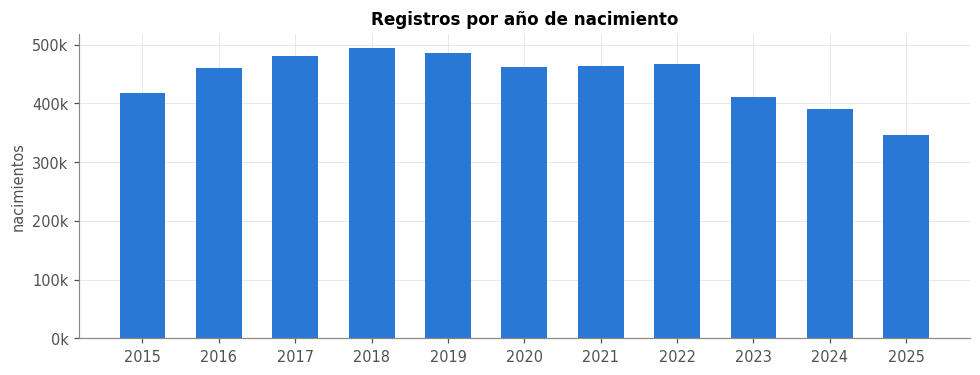

In [ ]:
# Cobertura temporal del registro: registros por año y meses presentes en 2025
anio = pd.to_numeric(raw["FecNac_Año"].astype(str), errors="coerce")
mes  = pd.to_numeric(raw["FecNac_Mes"].astype(str), errors="coerce")

cob = anio.value_counts().sort_index()
print(cob.to_string())
print("\nMeses presentes en 2025:", sorted(mes[anio == 2025].dropna().unique().astype(int)))
print(mes[anio == 2025].value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(cob.index.astype(int).astype(str), cob.values, color=SEQ, width=0.6)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.set_title("Registros por año de nacimiento"); ax.set_ylabel("nacimientos")
savefig("00_cobertura_anual")

**Cobertura temporal.** El número de registros sube de ≈ 417 k (2015) a ≈ 494 k (2018), baja en 2020
(≈ 462 k, año de pandemia) y desciende desde 2023 (≈ 410 k en 2023, ≈ 390 k en 2024). El patrón puede
reflejar tanto cambios en la cobertura del registro CNV como la evolución de la natalidad; **con estos datos
no es posible separar ambos efectos**, para lo cual habría que contrastar con las cifras oficiales de
nacimientos del INEI.

**2025 es un año parcial:** el corte del archivo es el 30/11/2025, por lo que solo contiene los meses 1 a 11
(≈ 347 k registros; anualizado, ≈ 378 k). Noviembre presenta un volumen ligeramente menor que el resto, compatible
con el ingreso tardío de certificados. Esto debe considerarse en el split temporal: el conjunto de test 2024–2025
incluye un año incompleto.

**Códigos de "dato faltante" del CNV.** No hay celdas vacías, pero el faltante viene **codificado**:
`IGNORADO`, `-1` y valores imposibles (peso `-1`, talla `5334`, edad gestacional `99`, edad materna `0`).
Hay que contarlos como faltantes. Ojo con un caso especial: en `Hijos_fallec_madre` el `-1` aparece en el
97 % de los registros y **no existe un código `0`**, así que se interpreta como "ninguno" y no como faltante.



**Discrepancia con el diccionario oficial.** El *Diccionario de Datos del CNV* (MINSA) define `-1` como
*ignorado* en `Hijos_fallec_madre`, y su dominio documentado (`-1, 1, 2, 3, 4, >=5`) no incluye el cero.
Sin embargo, es inverosímil que el 97 % de los registros tenga el dato ignorado: el `-1` está absorbiendo
el valor *ninguno*. Por eso se interpreta como 0. La contaminación por casos realmente ignorados se estima en
**≈ 1 %**, tomando como referencia la tasa de `-1` en `Num_embar_madre`, variable donde el cero no es posible
y el `-1` corresponde solo a ausencia real.



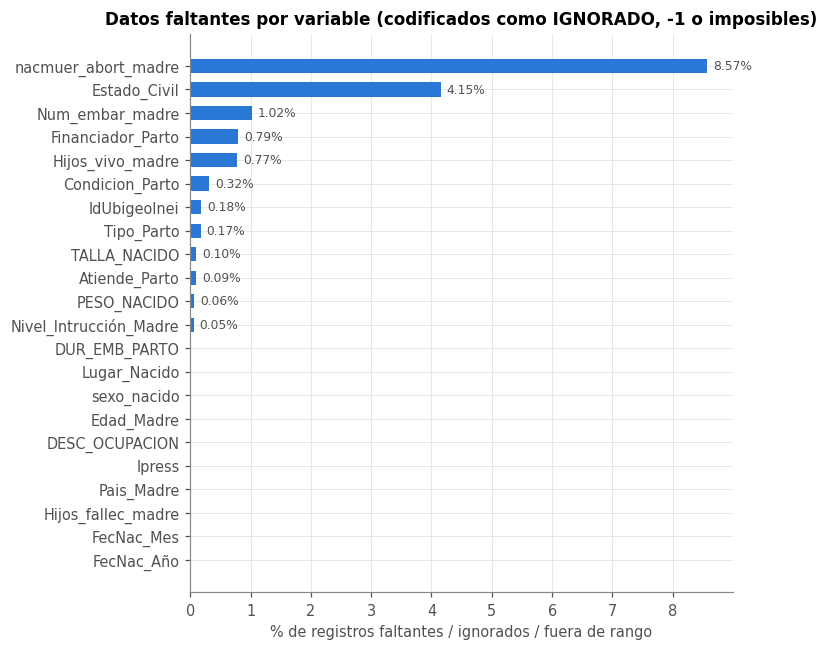

Ninguna variable supera el 40% de faltantes (criterio MFE de Khan et al.), así que ninguna se elimina por esta razón.


In [ ]:
num_raw = {c: pd.to_numeric(raw[c].astype(str), errors="coerce")
           for c in ["PESO_NACIDO", "TALLA_NACIDO", "DUR_EMB_PARTO", "Edad_Madre"]}
RANGOS = {"PESO_NACIDO": (500, 6000), "TALLA_NACIDO": (25, 65), "DUR_EMB_PARTO": (22, 42), "Edad_Madre": (10, 55)}

def pct_missing(c):
    s = raw[c].astype(str)
    if c in RANGOS:
        lo, hi = RANGOS[c]; return (~num_raw[c].between(lo, hi)).mean() * 100
    if c == "Hijos_fallec_madre":
        return 0.0
    return s.isin(["IGNORADO", "-1", ""]).mean() * 100

miss = pd.Series({c: pct_missing(c) for c in raw.columns}).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(miss.index, miss.values, color=SEQ, height=0.6)
for i, v in enumerate(miss.values):
    if v > 0.05: ax.text(v + 0.1, i, f"{v:.2f}%", va="center", fontsize=8, color="#52514e")
ax.set_xlabel("% de registros faltantes / ignorados / fuera de rango")
ax.set_title("Datos faltantes por variable (codificados como IGNORADO, -1 o imposibles)")
savefig("01_faltantes")
print("Ninguna variable supera el 40% de faltantes (criterio MFE de Khan et al.), así que ninguna se elimina por esta razón.")

## 3. Target: peso al nacer

Pesos fuera de [500, 6000] g (errores de digitación / -1): 3,024
count    4871486.0
mean        3249.9
std          523.4
min          500.0
25%         2970.0
50%         3274.0
75%         3580.0
max         6000.0
Name: PESO_NACIDO, dtype: float64


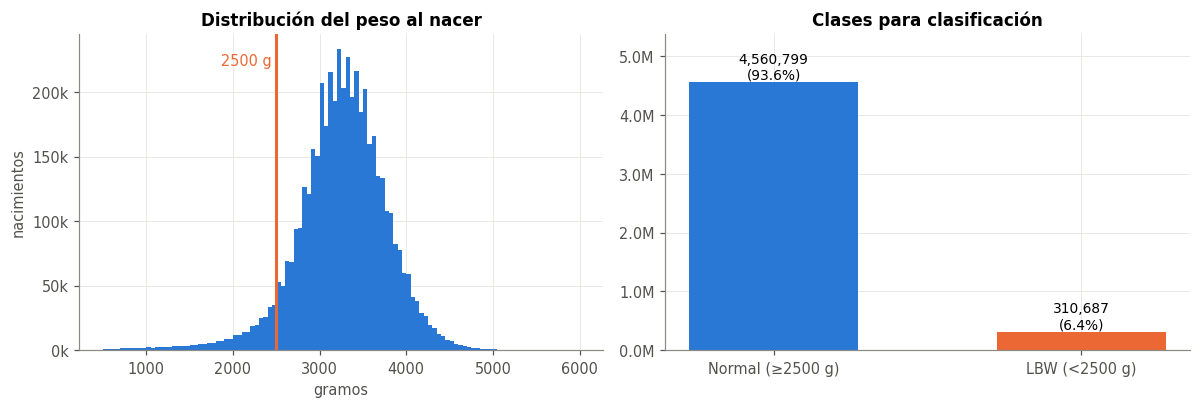

Desbalance: 1 LBW por cada 14.7 normales
Asimetría: -0.683 | Curtosis: 2.368


In [ ]:
peso = num_raw["PESO_NACIDO"]
valido = peso.between(500, 6000)
print(f"Pesos fuera de [500, 6000] g (errores de digitación / -1): {(~valido).sum():,}")
p = peso[valido]
print(p.describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(p, bins=110, color=SEQ)
ax[0].axvline(2500, color=LBW_C, lw=2); ax[0].text(2450, ax[0].get_ylim()[1]*0.9, "2500 g", ha="right", color=LBW_C)
ax[0].set_title("Distribución del peso al nacer"); ax[0].set_xlabel("gramos"); ax[0].set_ylabel("nacimientos")
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
lbw = (p < 2500)
cnt = lbw.value_counts().sort_index()
ax[1].bar(["Normal (≥2500 g)", "LBW (<2500 g)"], cnt.values, color=[NORMAL, LBW_C], width=0.55)
for i, v in enumerate(cnt.values):
    ax[1].text(i, v, f"{v:,}\n({v/cnt.sum():.1%})", ha="center", va="bottom", fontsize=9)
ax[1].set_title("Clases para clasificación"); ax[1].set_ylim(0, cnt.max()*1.18)
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
savefig("02_target")
print(f"Desbalance: 1 LBW por cada {cnt[False]/cnt[True]:.1f} normales")
print("Asimetría:", round(stats.skew(p), 3), "| Curtosis:", round(stats.kurtosis(p), 3))

**Lectura.** El peso tiene forma aproximadamente normal (media ≈ 3250 g) con una **cola izquierda larga** (prematuros).
La prevalencia de LBW es **≈ 6.4 %** (≈ 1:14.7), un desbalance mayor que en Khan (1:8) y Almeida (≈ 1:9.6).
Para clasificar hace falta balancear las clases (`class_weight="balanced"` o SMOTE) y reportar **recall, F1 y AUC de la clase LBW**, no solo accuracy:
un modelo que dice "normal" para todos ya saca 93.6 % de accuracy.

Los redondeos a 3000, 3200, 3500… (picos del histograma) son *heaping* de registro: los pesos se anotan redondeados.

In [ ]:
# Heaping en el umbral de clasificación: ¿hay acumulación artificial en 2500 g?
vecinos = [2450, 2470, 2480, 2490, 2500, 2510, 2520, 2530, 2550]
print(p.value_counts().reindex(vecinos).to_string())

esperado = p.value_counts().reindex([2480, 2490, 2510, 2520]).mean()   # conteo típico alrededor del umbral
exceso   = p.value_counts()[2500] - esperado
print(f"\nConteo en 2500 g     : {p.value_counts()[2500]:,}")
print(f"Conteo típico vecino : {esperado:,.0f}")
print(f"Exceso en 2500 g     : {exceso:,.0f}")
print(f"\nPrevalencia LBW (< 2500 g, OMS): {(p < 2500).mean():.2%}")
print(f"Prevalencia si fuera <= 2500 g : {(p <= 2500).mean():.2%}")

PESO_NACIDO
2450     6161
2470     4976
2480     5223
2490     4679
2500    16353
2510     5657
2520     6256
2530     6094
2550     8937

Conteo en 2500 g     : 16,353
Conteo típico vecino : 5,454
Exceso en 2500 g     : 10,899

Prevalencia LBW (< 2500 g, OMS): 6.38%
Prevalencia si fuera <= 2500 g : 6.71%


**Heaping en la frontera de la clase.** El valor 2500 g acumula ≈ 16 k registros, unas **3 veces** más que
sus vecinos (≈ 5–6 k en 2490 y 2510). Esto es relevante porque 2500 g es exactamente el umbral de la
definición OMS (LBW = peso **menor** a 2500 g): los recién nacidos registrados con 2500 g se clasifican como
*normales*. Si parte de ellos pesaba en realidad 2480–2499 g y el valor se redondeó al registrarlo, quedaron
mal etiquetados.

El impacto se acota con la prevalencia: con umbral `<= 2500` g pasaría de ≈ 6.4 % a ≈ 6.7 %. Se mantiene la
definición OMS, pero se reporta como **limitación de medición (ruido en la etiqueta)**, que afecta precisamente
a los casos fronterizos.

## 4. Limpieza y construcción de variables
| Variable original | Variable limpia | Transformación |
|---|---|---|
| PESO_NACIDO | `peso` / `LBW` | 500–6000 g; LBW = peso < 2500 |
| DUR_EMB_PARTO | `edad_gest` | 22–42 semanas (fuera → NaN) |
| Edad_Madre | `edad_madre` | 10–55 años |
| sexo_nacido | `sexo_fem` | 1 = femenino |
| Tipo_Parto | `emb_multiple` | 1 = doble/triple/más |
| Num_embar_madre | `n_embarazos` | `>=5`→5, `-1`→NaN |
| Hijos_vivo_madre | `hijos_vivos` | `>=5`→5, `-1`→NaN |
| Hijos_fallec_madre | `hijos_fallec` | `-1`→0, `>=5`→5 |
| nacmuer_abort_madre | `abortos_nacmuertos` | NINGUNO→0, "11 a más"→11, IGNORADO→NaN |
| Estado_Civil | `con_pareja` | casado/conviviente = 1; IGNORADO → NaN |
| Nivel_Intrucción_Madre | `educacion` | ordinal 0–7 |
| DESC_OCUPACION (2875 valores) | `ocupacion` | AMA DE CASA / TRABAJA |
| Pais_Madre | `extranjera` | 1 = no peruana |
| IdUbigeoInei | `departamento` | 2 primeros dígitos (25 dptos.) |
| Financiador_Parto | `financiador` | SIS / ESSALUD / PRIVADO / FFAA-PNP |
| TALLA_NACIDO, Condicion_Parto, Lugar_Nacido, Atiende_Parto | (se analizan, luego se evalúan para eliminar) | — |

In [ ]:
def to_num(s, mapping=None):
    s = raw[s].astype(str).replace(mapping or {})
    return pd.to_numeric(s, errors="coerce")

df = pd.DataFrame(index=raw.index)
df["peso"]       = num_raw["PESO_NACIDO"].where(num_raw["PESO_NACIDO"].between(500, 6000))
df["talla_rn"]   = num_raw["TALLA_NACIDO"].where(num_raw["TALLA_NACIDO"].between(25, 65))
df["edad_gest"]  = num_raw["DUR_EMB_PARTO"].where(num_raw["DUR_EMB_PARTO"].between(22, 42))
df["edad_madre"] = num_raw["Edad_Madre"].where(num_raw["Edad_Madre"].between(10, 55))
df["anio"]       = to_num("FecNac_Año")
df["mes"]        = to_num("FecNac_Mes")

df["sexo_fem"]     = raw["sexo_nacido"].map({"FEMENINO": 1, "MASCULINO": 0}).astype(float)
df["emb_multiple"] = raw["Tipo_Parto"].map({"UNICO": 0, "DOBLE": 1, "TRIPLE": 1, "MAS DE TRES": 1}).astype(float)
df["n_embarazos"]  = to_num("Num_embar_madre", {">=5": "5", "-1": "nan"})
df["hijos_vivos"]  = to_num("Hijos_vivo_madre", {">=5": "5", "-1": "nan"})
df["hijos_fallec"] = to_num("Hijos_fallec_madre", {">=5": "5", "-1": "0"})
df["abortos_nacmuertos"] = to_num("nacmuer_abort_madre", {"NINGUNO": "0", "11 a más": "11", "IGNORADO": "nan"})
df["con_pareja"]   = raw["Estado_Civil"].map({"CASADO": 1, "CONVIVIENTE": 1, "SOLTERO": 0, "DIVORCIADO": 0,
                                               "VIUDO": 0, "SEPARADO": 0}).astype(float)
EDU = {"NINGUN NIVEL/ILETRADO": 0, "INCIAL/PRE-ESCOLAR": 0, "PRIMARIA INCOMPLETA": 1, "PRIMARIA COMPLETA": 2,
       "SECUNDARIA INCOMPLETA": 3, "SECUNDARIA COMPLETA": 4, "SUPERIOR NO UNIV. INCOMPLETA": 5,
       "SUPERIOR UNIV. INCOMPLETA": 5, "SUPERIOR NO UNIV. COMPLETA": 6, "SUPERIOR UNIV. COMPLETA": 7}
df["educacion"] = raw["Nivel_Intrucción_Madre"].map(EDU).astype(float)

occ = raw["DESC_OCUPACION"].astype(str)
df["ocupacion"] = np.where(occ.eq("AMA DE CASA"), "AMA DE CASA", "TRABAJA")   # ##### NUEVO ###### el CNV prácticamente no registra "estudiante" (185 casos, 0.004 %) ##### FIN NUEVO ######
df["extranjera"]   = (raw["Pais_Madre"].astype(str) != "PERU").astype(float)
ubi = raw["IdUbigeoInei"].astype(str)
df["departamento"] = ubi.str.zfill(6).str[:2].where(~ubi.str.startswith("-"))   # "-1" = sin ubigeo → NaN
FIN = {"SIS": "SIS", "ESSALUD": "ESSALUD", "PARTICULAR": "PRIVADO", "PRIVADOS": "PRIVADO",
       "SANIDAD PNP": "FFAA-PNP", "SANIDAD NAVAL": "FFAA-PNP", "SANIDAD EP": "FFAA-PNP", "SANIDAD FAP": "FFAA-PNP"}
df["financiador"] = raw["Financiador_Parto"].map(FIN).astype(object)
df["cesarea"]     = raw["Condicion_Parto"].map({"CESAREA": 1, "EUTOCICO": 0, "INSTRUMENTADO": 0}).astype(float)
df["parto_en_establecimiento"] = raw["Lugar_Nacido"].map(lambda v: np.nan if v == "IGNORADO"
                                                          else float(v == "ESTABLECIMIENTO DE SALUD")).astype(float)
df["atiende"] = raw["Atiende_Parto"].replace({"IGNORADO": np.nan}).astype(object)
df["ipress"]  = raw["Ipress"].astype(str)

n0 = len(df)
df = df[df["peso"].notna()].copy()
df["LBW"] = (df["peso"] < 2500).astype(int)
print(f"Registros: {n0:,} → {len(df):,} (se eliminaron {n0-len(df):,} sin peso válido)")
print("Ocupación agrupada:\n", df["ocupacion"].value_counts(normalize=True).round(3))
df.isna().mean().mul(100).round(2).sort_values(ascending=False).head(10)

Registros: 4,874,510 → 4,871,486 (se eliminaron 3,024 sin peso válido)
Ocupación agrupada:
 ocupacion
AMA DE CASA    0.838
TRABAJA        0.162
Name: proportion, dtype: float64


,0
abortos_nacmuertos,8.56
con_pareja,4.15
n_embarazos,1.02
financiador,0.79
hijos_vivos,0.77
cesarea,0.32
departamento,0.18
emb_multiple,0.17
atiende,0.09
talla_rn,0.08


In [ ]:
# ¿La ausencia en abortos_nacmuertos está asociada al LBW? (valida la imputación posterior)
m = df["abortos_nacmuertos"].isna()
print(f"% faltante                 : {m.mean()*100:.2f}%")
print(f"%LBW con dato faltante     : {df.loc[m,  'LBW'].mean()*100:.2f}%")
print(f"%LBW con dato presente     : {df.loc[~m, 'LBW'].mean()*100:.2f}%")
print(f"Razón (faltante / presente): {df.loc[m, 'LBW'].mean() / df.loc[~m, 'LBW'].mean():.2f}")


% faltante                 : 8.56%
%LBW con dato faltante     : 6.60%
%LBW con dato presente     : 6.36%
Razón (faltante / presente): 1.04


**Patrón de ausencia.** `abortos_nacmuertos` tiene ≈ 8.6 % de faltantes (`IGNORADO`). La prevalencia de LBW es
prácticamente igual entre registros con dato faltante (≈ 6.60 %) y con dato presente (≈ 6.36 %), con una razón
de ≈ 1.04. **La ausencia no está asociada al desenlace**, por lo que la imputación con mediana o moda propuesta
para el modelado es defendible y no elimina una señal predictiva.


## 5. Análisis univariado

In [ ]:
NUM = ["edad_gest", "edad_madre", "n_embarazos", "hijos_vivos", "abortos_nacmuertos", "educacion", "talla_rn"]
df[NUM + ["peso"]].describe(percentiles=[.01, .25, .5, .75, .99]).T.round(2)

,count,mean,std,min,1%,25%,50%,75%,99%,max
edad_gest,4871294.0,38.62,1.71,22.0,32.0,38.0,39.0,40.0,41.0,42.0
edad_madre,4871390.0,28.30,6.94,10.0,16.0,23.0,28.0,33.0,43.0,55.0
n_embarazos,4821706.0,2.40,1.28,1.0,1.0,1.0,2.0,3.0,5.0,5.0
hijos_vivos,4834011.0,2.11,1.15,1.0,1.0,1.0,2.0,3.0,5.0,5.0
abortos_nacmuertos,4454265.0,0.37,0.72,0.0,0.0,0.0,0.0,1.0,3.0,11.0
educacion,4868838.0,4.15,1.65,0.0,1.0,3.0,4.0,5.0,7.0,7.0
talla_rn,4867602.0,49.15,2.54,25.0,40.0,48.0,49.5,50.5,54.0,65.0
peso,4871486.0,3249.93,523.37,500.0,1590.0,2970.0,3274.0,3580.0,4400.0,6000.0


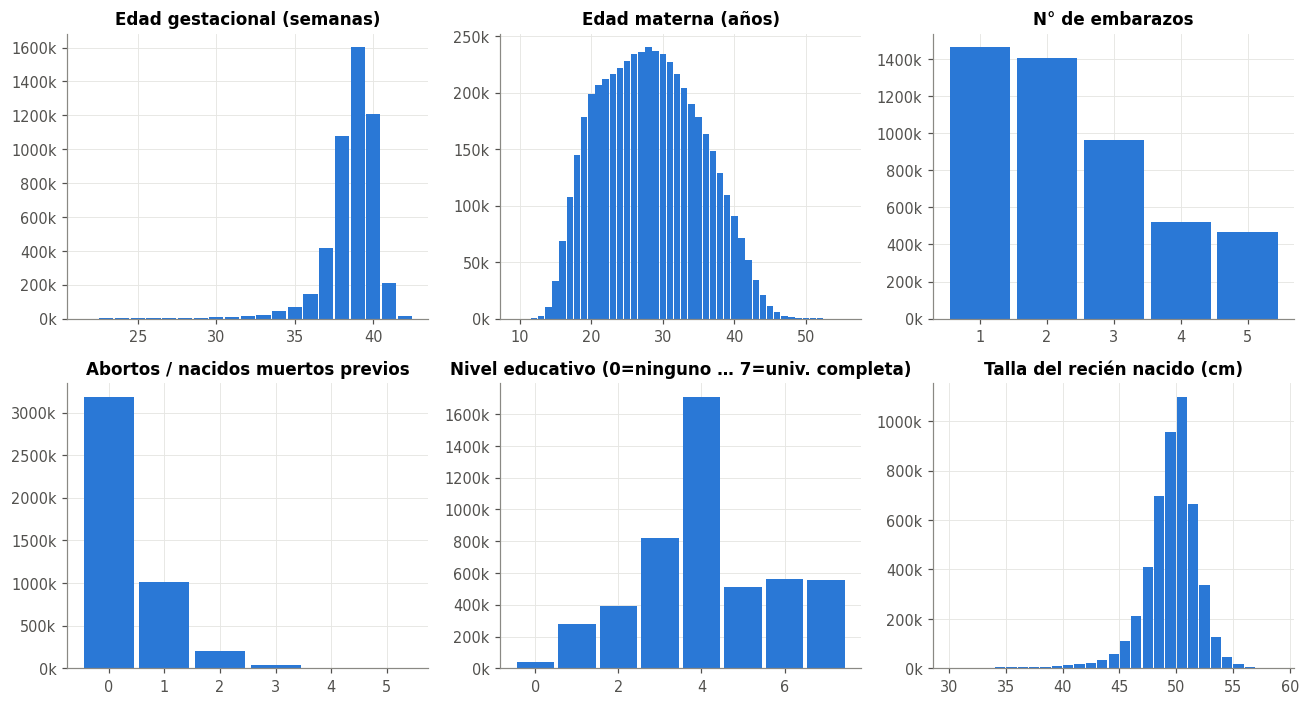

Prematuros (<37 sem): 6.9% | Madres ≤19 años: 11.2% | ≥35 años: 21.0%


In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6.5))
specs = [("edad_gest", "Edad gestacional (semanas)", np.arange(21.5, 43)),
         ("edad_madre", "Edad materna (años)", np.arange(9.5, 56)),
         ("n_embarazos", "N° de embarazos", np.arange(0.5, 6)),
         ("abortos_nacmuertos", "Abortos / nacidos muertos previos", np.arange(-0.5, 6)),
         ("educacion", "Nivel educativo (0=ninguno … 7=univ. completa)", np.arange(-0.5, 8)),
         ("talla_rn", "Talla del recién nacido (cm)", np.arange(30, 60))]
for ax, (c, t, b) in zip(axs.flat, specs):
    ax.hist(df[c].dropna(), bins=b, color=SEQ, rwidth=0.9)
    ax.set_title(t); ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
savefig("03_univariado_numericas")
print("Prematuros (<37 sem):", f"{(df.edad_gest < 37).mean():.1%}",
      "| Madres ≤19 años:", f"{(df.edad_madre <= 19).mean():.1%}", "| ≥35 años:", f"{(df.edad_madre >= 35).mean():.1%}")

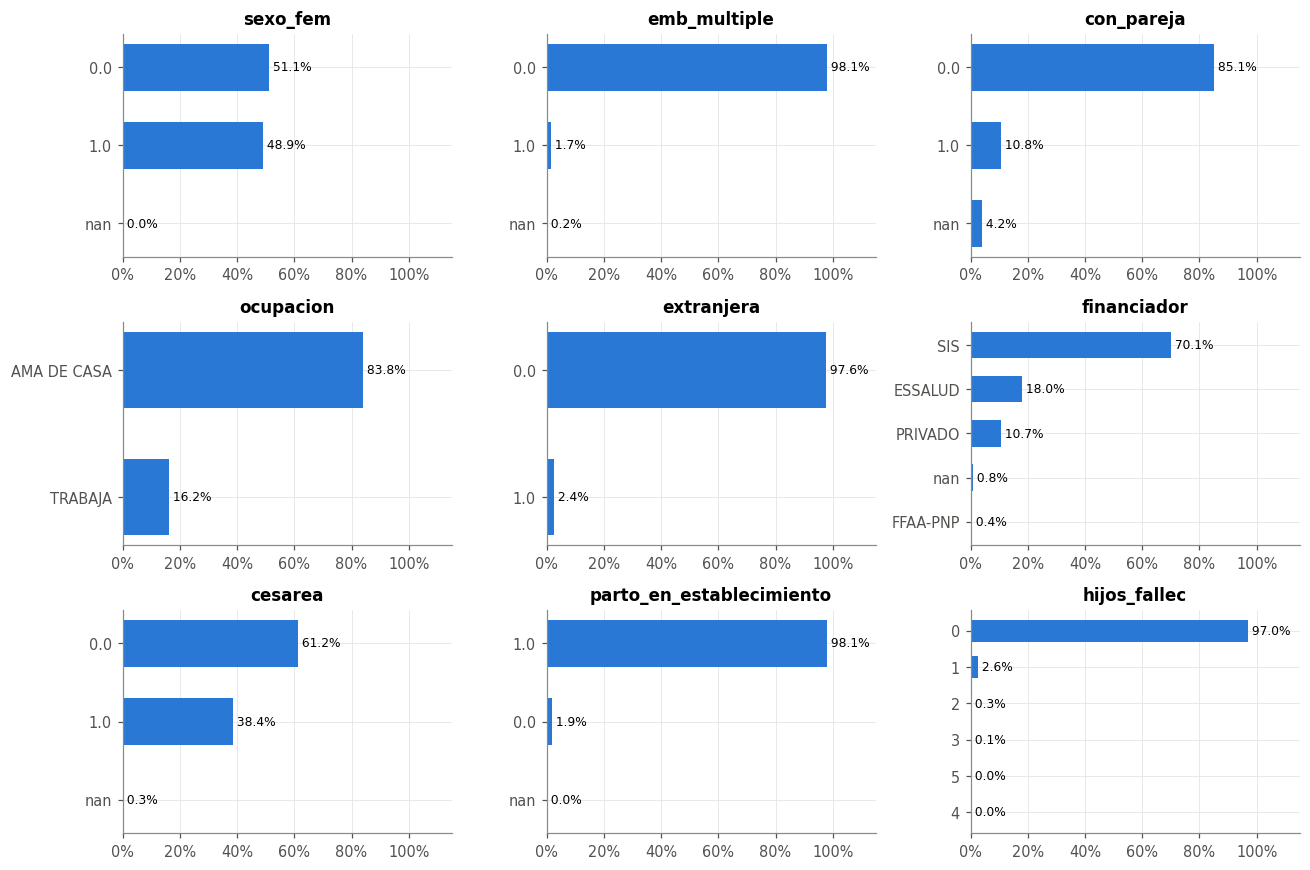

In [ ]:
CAT = ["sexo_fem", "emb_multiple", "con_pareja", "ocupacion", "extranjera", "financiador", "cesarea",
       "parto_en_establecimiento", "hijos_fallec"]
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
for ax, c in zip(axs.flat, CAT):
    vc = df[c].value_counts(normalize=True, dropna=False).sort_values()
    ax.barh([str(v) for v in vc.index], vc.values, color=SEQ, height=0.6)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.set_title(c)
    for i, v in enumerate(vc.values): ax.text(v, i, f" {v:.1%}", va="center", fontsize=8)
    ax.set_xlim(0, 1.15)
savefig("04_univariado_categoricas")

**Hallazgos univariados**
- `parto_en_establecimiento` (98 %) y `extranjera` (2.4 %) son **casi constantes**: aportan muy poca información.
- `con_pareja`: el 85 % figura como SOLTERO, algo poco creíble para Perú, donde la convivencia es muy común. Seguramente
  "soltera" se registra por defecto (el número de CONVIVIENTE recién sube desde 2019). Es una variable **ruidosa**.
- `ocupacion`: el 84 % es AMA DE CASA, así que es poco informativa.
- `hijos_fallec`: el 97 % tiene 0.


- `abortos_nacmuertos`: hay más registros con 10 que con 9 (974 frente a 218), cuando la frecuencia decrece de
  forma regular de 6 a 9. Es **preferencia por números redondos** al registrar, el mismo fenómeno que el heaping
  del peso. Afecta a muy pocos casos y no condiciona el modelado.



## 6. Análisis bivariado vs LBW

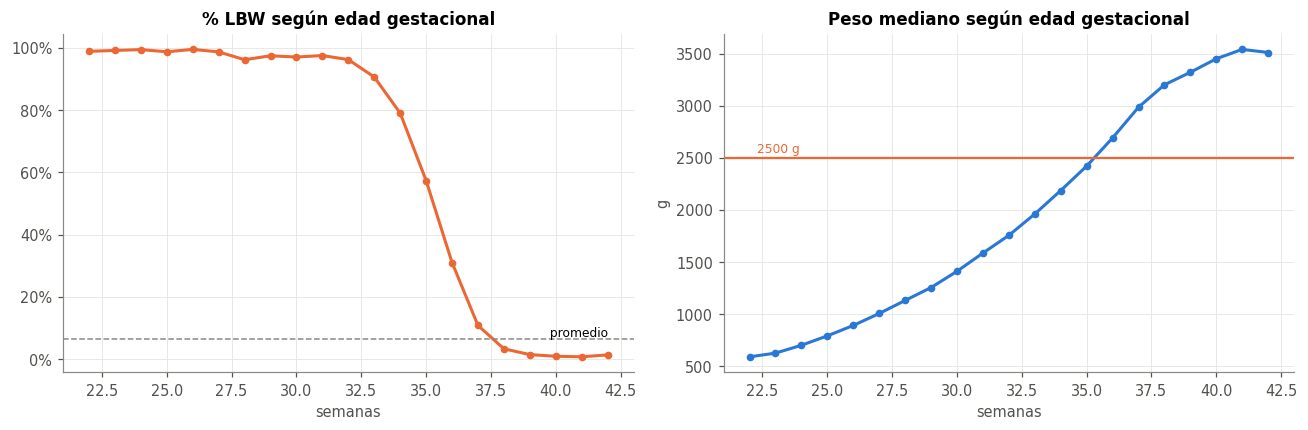

           %LBW     size
edad_gest               
30.0       97.0     8861
34.0       79.0    42542
36.0       31.0   144892
37.0       10.8   418751
38.0        3.3  1080478
39.0        1.4  1602446
40.0        0.9  1208004


In [ ]:
def lbw_rate(col, data=df, bins=None, labels=None):
    x = pd.cut(data[col], bins=bins, labels=labels) if bins is not None else data[col]
    return data.groupby(x, observed=True)["LBW"].agg(["mean", "size"])

base = df["LBW"].mean()
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
r = lbw_rate("edad_gest")
axs[0].plot(r.index, r["mean"], color=LBW_C, lw=2, marker="o", ms=4)
axs[0].axhline(base, color="#8a8984", ls="--", lw=1); axs[0].text(42, base, " promedio", va="bottom", ha="right", fontsize=8)
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(1)); axs[0].set_xlabel("semanas")
axs[0].set_title("% LBW según edad gestacional")
g = df.groupby("edad_gest")["peso"].median()
axs[1].plot(g.index, g.values, color=NORMAL, lw=2, marker="o", ms=4)
axs[1].axhline(2500, color=LBW_C, lw=1.5); axs[1].text(22.3, 2550, "2500 g", color=LBW_C, fontsize=8)
axs[1].set_title("Peso mediano según edad gestacional"); axs[1].set_xlabel("semanas"); axs[1].set_ylabel("g")
savefig("05_edad_gestacional")
print(r.loc[[30, 34, 36, 37, 38, 39, 40]].assign(mean=lambda d: (d["mean"]*100).round(1)).rename(columns={"mean": "%LBW"}))

La **edad gestacional es, por lejos, el predictor dominante**: por debajo de 34 semanas casi todos los recién nacidos son LBW,
y desde las 38 semanas el porcentaje baja a ≈ 2–3 %. Esto coincide con Khan et al. (gestational age es una de las top 3).
**Advertencia:** la edad gestacional *al parto* solo se conoce cuando el bebé ya nació, así que un modelo que la usa clasifica pero no "predice antes del parto".
Conviene entrenar **con y sin** ella para mostrar cuánto aportan las demás variables.

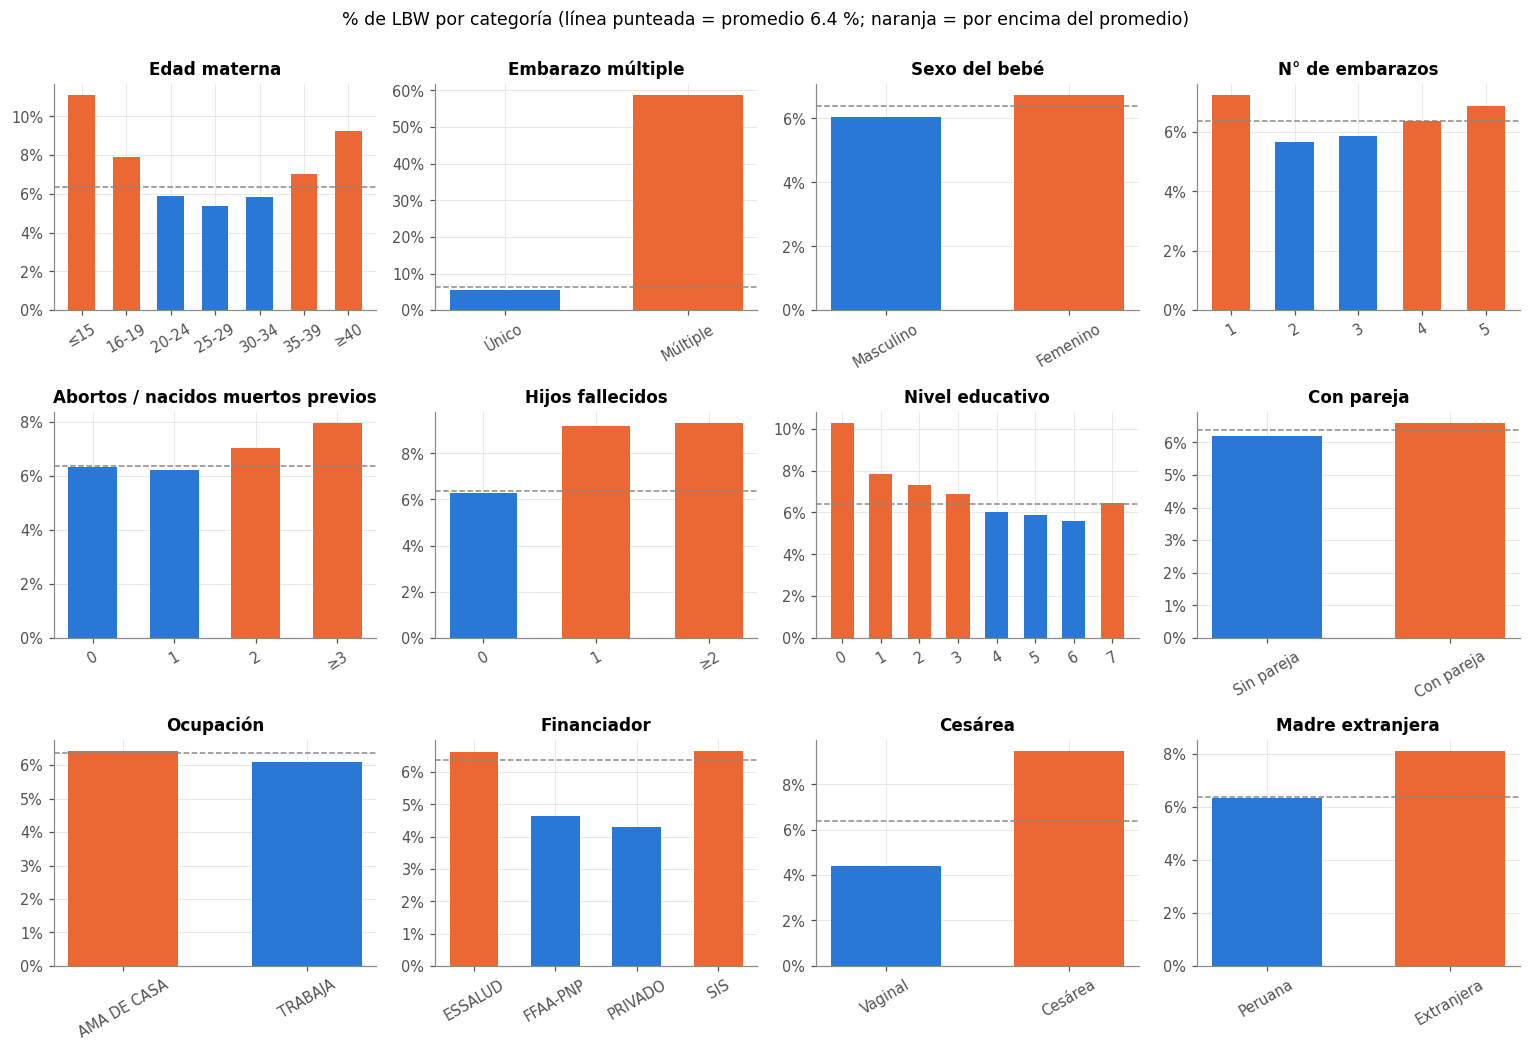

In [ ]:
fig, axs = plt.subplots(3, 4, figsize=(14, 9.5))
plots = [
    ("Edad materna", lbw_rate("edad_madre", bins=[9, 15, 19, 24, 29, 34, 39, 55],
                              labels=["≤15", "16-19", "20-24", "25-29", "30-34", "35-39", "≥40"])),
    ("Embarazo múltiple", lbw_rate("emb_multiple").rename({0: "Único", 1: "Múltiple"})),
    ("Sexo del bebé", lbw_rate("sexo_fem").rename({0: "Masculino", 1: "Femenino"})),
    ("N° de embarazos", lbw_rate("n_embarazos")),
    ("Abortos / nacidos muertos previos", lbw_rate("abortos_nacmuertos", bins=[-1, 0, 1, 2, 20], labels=["0", "1", "2", "≥3"])),
    ("Hijos fallecidos", lbw_rate("hijos_fallec", bins=[-1, 0, 1, 20], labels=["0", "1", "≥2"])),
    ("Nivel educativo", lbw_rate("educacion")),
    ("Con pareja", lbw_rate("con_pareja").rename({0: "Sin pareja", 1: "Con pareja"})),
    ("Ocupación", lbw_rate("ocupacion")),
    ("Financiador", lbw_rate("financiador")),
    ("Cesárea", lbw_rate("cesarea").rename({0: "Vaginal", 1: "Cesárea"})),
    ("Madre extranjera", lbw_rate("extranjera").rename({0: "Peruana", 1: "Extranjera"})),
]
for ax, (t, r) in zip(axs.flat, plots):
    cols = [LBW_C if v > base else NORMAL for v in r["mean"]]
    ax.bar([f"{v:g}" if isinstance(v, float) else str(v) for v in r.index], r["mean"].values, color=cols, width=0.6)
    ax.axhline(base, color="#8a8984", ls="--", lw=1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.set_title(t)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("% de LBW por categoría (línea punteada = promedio 6.4 %; naranja = por encima del promedio)", y=1.0)
savefig("06_bivariado_categoricas")

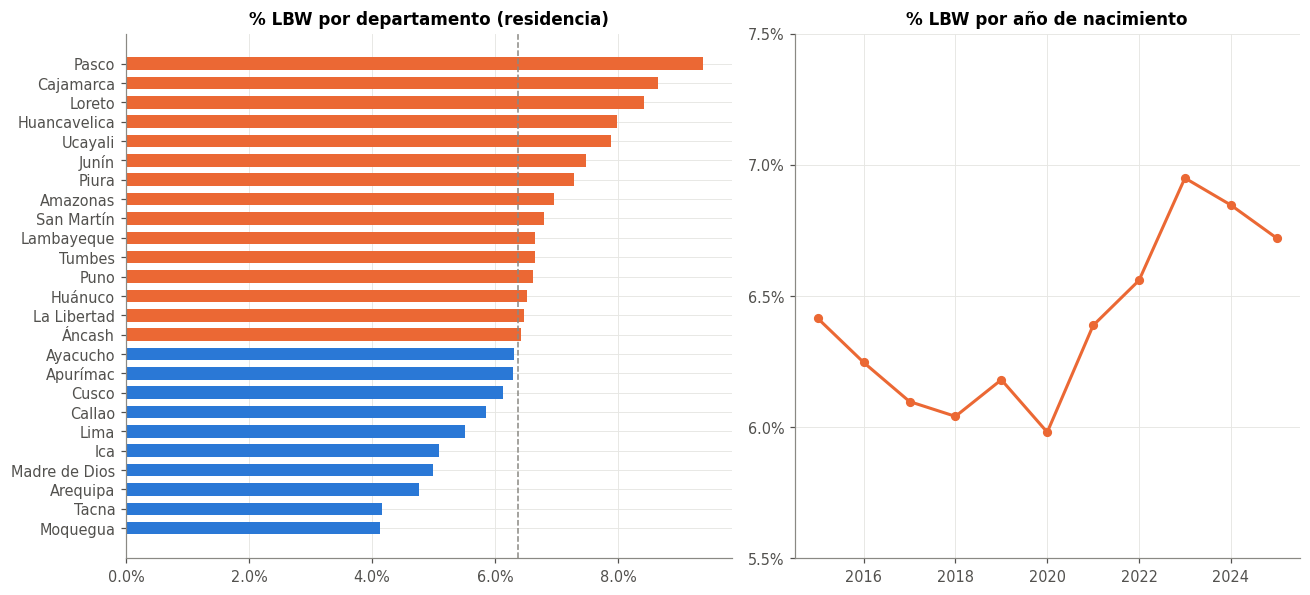

In [ ]:
r = df.groupby("departamento")["LBW"].agg(["mean", "size"]).sort_values("mean")
DEP = {"01":"Amazonas","02":"Áncash","03":"Apurímac","04":"Arequipa","05":"Ayacucho","06":"Cajamarca","07":"Callao",
       "08":"Cusco","09":"Huancavelica","10":"Huánuco","11":"Ica","12":"Junín","13":"La Libertad","14":"Lambayeque",
       "15":"Lima","16":"Loreto","17":"Madre de Dios","18":"Moquegua","19":"Pasco","20":"Piura","21":"Puno",
       "22":"San Martín","23":"Tacna","24":"Tumbes","25":"Ucayali"}
r.index = r.index.map(lambda k: DEP.get(k, k))
fig, axs = plt.subplots(1, 2, figsize=(12, 5.5), gridspec_kw={"width_ratios": [1.2, 1]})
axs[0].barh(list(r.index), r["mean"].values, color=[LBW_C if v > base else NORMAL for v in r["mean"]], height=0.65)
axs[0].axvline(base, color="#8a8984", ls="--", lw=1)
axs[0].xaxis.set_major_formatter(mtick.PercentFormatter(1)); axs[0].set_title("% LBW por departamento (residencia)")
y = df.groupby("anio")["LBW"].mean()
axs[1].plot(y.index, y.values, color=LBW_C, lw=2, marker="o", ms=5)
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=1)); axs[1].set_title("% LBW por año de nacimiento")
axs[1].set_ylim(0.055, 0.075); axs[1].yaxis.set_major_locator(mtick.MultipleLocator(0.005))
savefig("07_departamento_anio")

**Hallazgos bivariados** (coinciden con la Tabla 2 de Almeida et al.)
- **Embarazo múltiple**: **58.7 %** de LBW frente a 5.5 % en embarazos únicos. Es el factor de riesgo más fuerte después de la edad gestacional.
- **Edad materna**: forma de **U**. ≤ 15 años: 11.1 %; 25–29: 5.4 %; ≥ 40: 9.2 %.
- **Sexo femenino**: algo más de LBW (6.7 % frente a 6.0 %), lo esperado biológicamente.
- **Primer embarazo** (7.3 %), **hijos fallecidos previos** (≈ 9–10 % frente a 6.3 %) y **≥ 3 abortos / nacidos muertos** (≈ 8 %): más riesgo.
- **Educación**: gradiente claro, de 10.3 % sin instrucción a 5.6 % con superior no universitaria.
- **Financiador**: SIS / EsSalud ≈ 6.6 % frente a privado 4.3 % (proxy socioeconómico).
- **Departamento**: diferencias regionales marcadas, más altas en Pasco (9.4 %), Cajamarca, Loreto, Huancavelica y Ucayali, y más bajas
  en Moquegua, Tacna y Arequipa (≈ 4.1–4.8 %). Esto refleja pobreza, acceso a salud y altitud.
- **Cesárea**: más LBW, pero es una **consecuencia** del cuadro clínico (se decide en el parto), no una causa → *leakage*.

- **Ocupación** y **estado civil**: diferencias mínimas (V de Cramér con LBW ≈ 0.003 y ≈ 0.007, respectivamente).


- **Año**: la variación es pequeña (6.1–7.0 %). No aporta como predictor, pero sí sirve para una partición temporal train/test.

In [ ]:

# Pruebas estadísticas: numéricas → Mann-Whitney U; categóricas → Chi² (sobre una muestra de 300k por costo computacional).
# Con este tamaño muestral casi toda prueba resulta significativa: la relevancia de cada variable se evalúa por la
# magnitud del efecto (diferencia de tasas, V de Cramér), no por el p-valor.

smp = df.sample(300_000, random_state=SEED)
rows = []
for c in ["edad_gest", "edad_madre", "n_embarazos", "hijos_vivos", "abortos_nacmuertos", "educacion", "talla_rn"]:
    a, b = smp.loc[smp.LBW == 1, c].dropna(), smp.loc[smp.LBW == 0, c].dropna()
    U, pval = stats.mannwhitneyu(a, b)
    rows.append([c, "Mann-Whitney", f"{a.median():.1f} vs {b.median():.1f}", pval])
for c in ["sexo_fem", "emb_multiple", "hijos_fallec", "con_pareja", "ocupacion", "extranjera", "departamento",
          "financiador", "cesarea", "parto_en_establecimiento"]:
    ct = pd.crosstab(smp[c], smp.LBW)
    chi2, pval, *_ = stats.chi2_contingency(ct)
    rows.append([c, "Chi²", f"χ²={chi2:,.0f}", pval])
pruebas = pd.DataFrame(rows, columns=["variable", "prueba", "estadístico / medianas (LBW vs normal)", "p-valor"])
pruebas["significativo (p<0.05)"] = pruebas["p-valor"] < 0.05
pruebas

,variable,prueba,estadístico / medianas (LBW vs normal),p-valor,significativo (p<0.05)
0,edad_gest,Mann-Whitney,36.0 vs 39.0,0.000000e+00,True
1,edad_madre,Mann-Whitney,28.0 vs 28.0,5.338266e-06,True
2,n_embarazos,Mann-Whitney,2.0 vs 2.0,5.853437e-08,True
3,hijos_vivos,Mann-Whitney,2.0 vs 2.0,6.439658e-03,True
4,abortos_nacmuertos,Mann-Whitney,0.0 vs 0.0,1.143773e-03,True
5,educacion,Mann-Whitney,4.0 vs 4.0,2.095881e-22,True
6,talla_rn,Mann-Whitney,45.0 vs 50.0,0.000000e+00,True
7,sexo_fem,Chi²,χ²=60,9.493927e-15,True
8,emb_multiple,Chi²,"χ²=25,442",0.000000e+00,True
9,hijos_fallec,Chi²,χ²=159,1.409886e-32,True


## 7. Correlación y redundancia entre features
- Numéricas: correlación de **Spearman** (robusta a la asimetría y a variables ordinales).
- Todas las variables, incluidas las categóricas: **V de Cramér** (0 = independientes, 1 = totalmente asociadas).

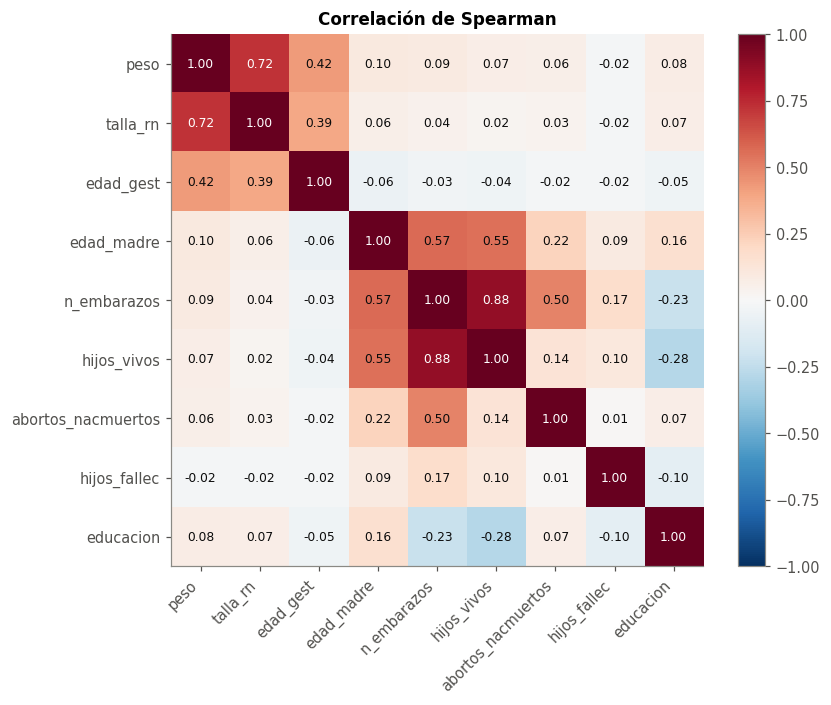

In [ ]:
NUMC = ["peso", "talla_rn", "edad_gest", "edad_madre", "n_embarazos", "hijos_vivos", "abortos_nacmuertos",
        "hijos_fallec", "educacion"]
corr = df[NUMC].sample(500_000, random_state=SEED).corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(NUMC)), NUMC, rotation=45, ha="right"); ax.set_yticks(range(len(NUMC)), NUMC); ax.grid(False)
for i in range(len(NUMC)):
    for j in range(len(NUMC)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "#0b0b0b")
plt.colorbar(im, fraction=0.04); ax.set_title("Correlación de Spearman")
savefig("08_spearman")

- `talla_rn` ↔ `peso`: ρ ≈ 0.7. La talla del recién nacido se mide **en el mismo momento que el peso**, así que usarla es
  **data leakage**: el modelo "haría trampa". **Importante:** esta columna es la talla del *bebé*, no la de la madre.
  La "talla de la madre" que usaba Khan et al. **no existe en el CNV**.
- `n_embarazos` ↔ `hijos_vivos`: ρ ≈ 0.9, **redundantes**. Se queda una sola.

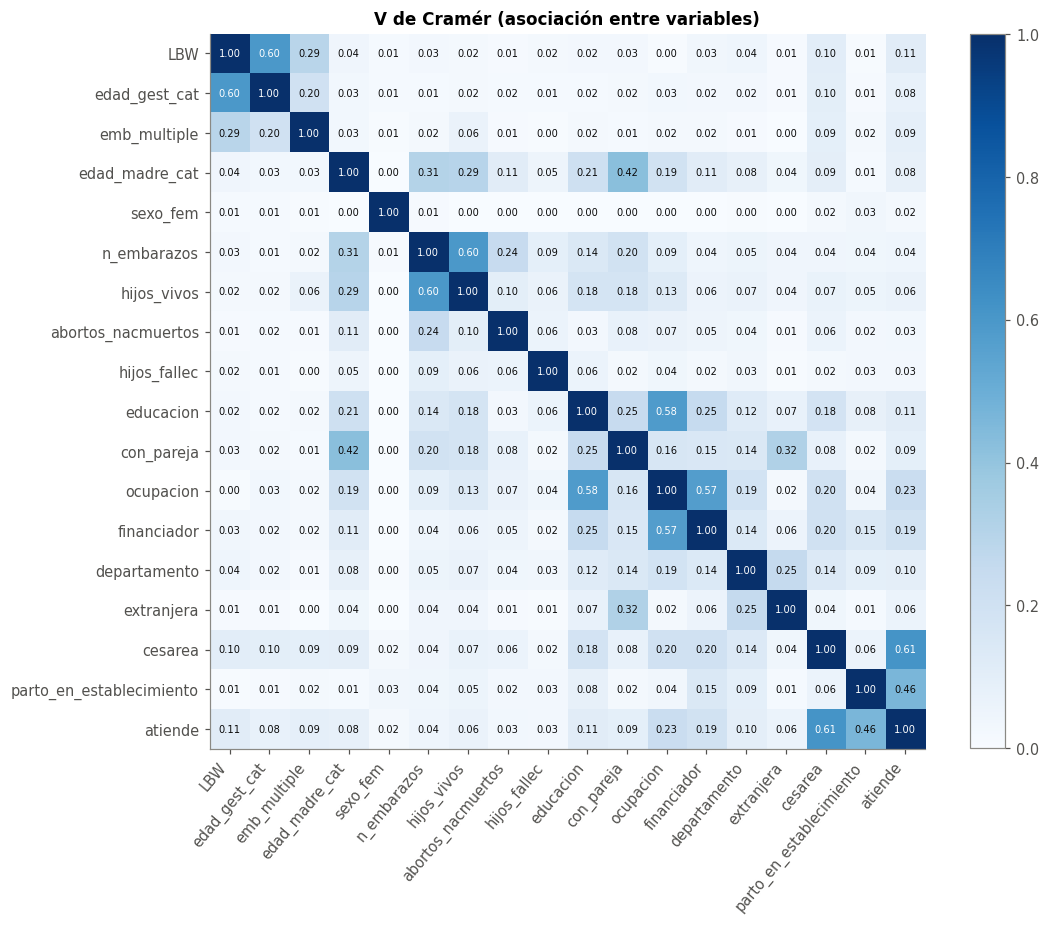

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum(); r, k = ct.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(1e-12, min(kc - 1, rc - 1)))

s2 = df.sample(400_000, random_state=SEED).copy()
s2["edad_gest_cat"]  = pd.cut(s2.edad_gest, [21, 31, 36, 41, 43]).astype(str)
s2["edad_madre_cat"] = pd.cut(s2.edad_madre, [9, 19, 34, 55]).astype(str)
CV = ["LBW", "edad_gest_cat", "emb_multiple", "edad_madre_cat", "sexo_fem", "n_embarazos", "hijos_vivos",
      "abortos_nacmuertos", "hijos_fallec", "educacion", "con_pareja", "ocupacion", "financiador",
      "departamento", "extranjera", "cesarea", "parto_en_establecimiento", "atiende"]
M = pd.DataFrame(index=CV, columns=CV, dtype=float)
for i, a in enumerate(CV):
    for b in CV[i:]:
        v = 1.0 if a == b else cramers_v(s2[a].astype(str), s2[b].astype(str))
        M.loc[a, b] = M.loc[b, a] = v
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(M.values.astype(float), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CV)), CV, rotation=50, ha="right"); ax.set_yticks(range(len(CV)), CV); ax.grid(False)
for i in range(len(CV)):
    for j in range(len(CV)):
        v = M.iloc[i, j]; ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5, color="white" if v > 0.5 else "#0b0b0b")
plt.colorbar(im, fraction=0.04); ax.set_title("V de Cramér (asociación entre variables)")
savefig("09_cramers_v")

- `atiende` ↔ `parto_en_establecimiento` ↔ `financiador`: están **fuertemente asociadas**, porque todas describen el *lugar y la forma* del parto.
- La fila **LBW** muestra la relevancia de cada variable: `edad_gest_cat` y `emb_multiple` dominan, y el resto tiene una asociación débil (< 0.1).

## 8. Reducción de features
Se aplica un embudo de 4 filtros, como en los papers (Khan: criterio MFE + votación de métodos de FS;
Almeida: conocimiento del dominio + eliminación de colinealidad):

| Filtro | Criterio |
|---|---|
| F1. Dominio / leakage | Se elimina lo que **no se conoce antes del parto** o es otra medida del resultado |
| F2. Calidad | Faltantes > 40 % (MFE) o casi constante (> 95 % en un valor), o IDs de alta cardinalidad |
| F3. Redundancia | Spearman > 0.8 o V de Cramér > 0.7 entre dos features → se queda la más informativa |
| F4. Relevancia | Ranking con **3 métodos**: V de Cramér con LBW, **información mutua** e **importancia por permutación** (Random Forest) |



**Nota metodológica.** El ranking de relevancia (F4) usa la variable objetivo y se calcula sobre una muestra
del dataset completo, antes de definir la partición train/test. En sentido estricto, la selección debería
realizarse solo sobre el conjunto de entrenamiento. En este caso el resultado no depende de esa elección: las
dos variables descartadas por relevancia (`con_pareja` y `ocupacion`) tienen importancia ≈ 0 en los tres métodos.



In [ ]:
filtros = pd.DataFrame([
    ["FecNac_Año / Mes", "F1", "Fecha de nacimiento: no es un factor de riesgo (se usa solo para el split temporal)"],
    ["TALLA_NACIDO (talla_rn)", "F1", "Leakage: medida del RN al nacer, ρ≈0.7 con el peso"],
    ["Condicion_Parto (cesárea)", "F1", "Se decide en el parto, es consecuencia del cuadro (leakage)"],
    ["Atiende_Parto", "F1/F3", "Circunstancia del parto; redundante con lugar/financiador"],
    ["Lugar_Nacido", "F1/F2", "Circunstancia del parto; casi constante (98 % establecimiento)"],
    ["Ipress", "F2", "ID de establecimiento, 2314 valores (alta cardinalidad)"],
    ["IdUbigeoInei", "F2", "1893 distritos → se resume en departamento (25)"],
    ["DESC_OCUPACION", "F2", "2875 valores → se resume en 2 grupos (ama de casa / trabaja)"],
    ["Hijos_vivo_madre", "F3", "ρ≈0.9 con Num_embar_madre (redundante)"],
    ["Pais_Madre (extranjera)", "F2", "Casi constante (97.6 % peruana)"],
], columns=["variable original", "filtro", "motivo de eliminación"])
filtros

,variable original,filtro,motivo de eliminación
0,FecNac_Año / Mes,F1,Fecha de nacimiento: no es un factor de riesgo...
1,TALLA_NACIDO (talla_rn),F1,"Leakage: medida del RN al nacer, ρ≈0.7 con el ..."
2,Condicion_Parto (cesárea),F1,"Se decide en el parto, es consecuencia del cua..."
3,Atiende_Parto,F1/F3,Circunstancia del parto; redundante con lugar/...
4,Lugar_Nacido,F1/F2,Circunstancia del parto; casi constante (98 % ...
5,Ipress,F2,"ID de establecimiento, 2314 valores (alta card..."
6,IdUbigeoInei,F2,1893 distritos → se resume en departamento (25)
7,DESC_OCUPACION,F2,2875 valores → se resume en 2 grupos (ama de c...
8,Hijos_vivo_madre,F3,ρ≈0.9 con Num_embar_madre (redundante)
9,Pais_Madre (extranjera),F2,Casi constante (97.6 % peruana)


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

CANDIDATAS = ["edad_gest", "emb_multiple", "edad_madre", "sexo_fem", "n_embarazos", "abortos_nacmuertos",
              "hijos_fallec", "educacion", "con_pareja", "ocupacion", "financiador", "departamento"]
sm = df.sample(300_000, random_state=SEED)
X = sm[CANDIDATAS].copy()
for c in ["ocupacion", "financiador", "departamento"]:
    X[c] = X[c].astype("category").cat.codes          # códigos para MI / RF
X = X.fillna(X.median(numeric_only=True))
y = sm["LBW"].values
discrete = [c != "edad_gest" and c != "edad_madre" for c in CANDIDATAS]

mi = pd.Series(mutual_info_classif(X, y, discrete_features=discrete, random_state=SEED), index=CANDIDATAS)

cv_lbw = pd.Series({c: cramers_v(pd.cut(sm[c], 10).astype(str) if c in ["edad_gest", "edad_madre"] else sm[c].astype(str),
                                 sm["LBW"]) for c in CANDIDATAS})

n_tr = 200_000
rf = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=20, class_weight="balanced",
                            n_jobs=-1, random_state=SEED).fit(X.iloc[:n_tr], y[:n_tr])
print("AUC RF (holdout de la muestra):", round(roc_auc_score(y[n_tr:], rf.predict_proba(X.iloc[n_tr:])[:, 1]), 3))
pi = permutation_importance(rf, X.iloc[n_tr:], y[n_tr:], scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
perm = pd.Series(pi.importances_mean, index=CANDIDATAS)

rank = pd.DataFrame({"Cramér_V": cv_lbw, "Info_mutua": mi, "Permutación_ΔAUC": perm})
for c in rank.columns: rank[f"rank_{c}"] = rank[c].rank(ascending=False)
rank["rank_promedio"] = rank.filter(like="rank_").mean(axis=1)
rank = rank.sort_values("rank_promedio")
rank.round(4)

AUC RF (holdout de la muestra): 0.901


,Cramér_V,Info_mutua,Permutación_ΔAUC,rank_Cramér_V,rank_Info_mutua,rank_Permutación_ΔAUC,rank_promedio
edad_gest,0.6378,0.1162,0.3051,1.0,1.0,1.0,1.0000
emb_multiple,0.2913,0.0181,0.0073,2.0,2.0,2.0,2.0000
departamento,0.0449,0.0010,0.0034,4.0,4.0,4.0,4.0000
edad_madre,0.0499,0.0032,0.0006,3.0,3.0,8.0,4.6667
financiador,0.0338,0.0006,0.0033,5.0,5.0,5.0,5.0000
n_embarazos,0.0241,0.0003,0.0039,8.0,6.0,3.0,5.6667
educacion,0.0252,0.0003,0.0030,7.0,7.0,6.0,6.6667
sexo_fem,0.0140,0.0001,0.0023,10.0,9.0,7.0,8.6667
hijos_fallec,0.0227,0.0002,0.0002,9.0,8.0,10.0,9.0000
con_pareja,0.0253,0.0000,-0.0000,6.0,11.0,11.0,9.3333


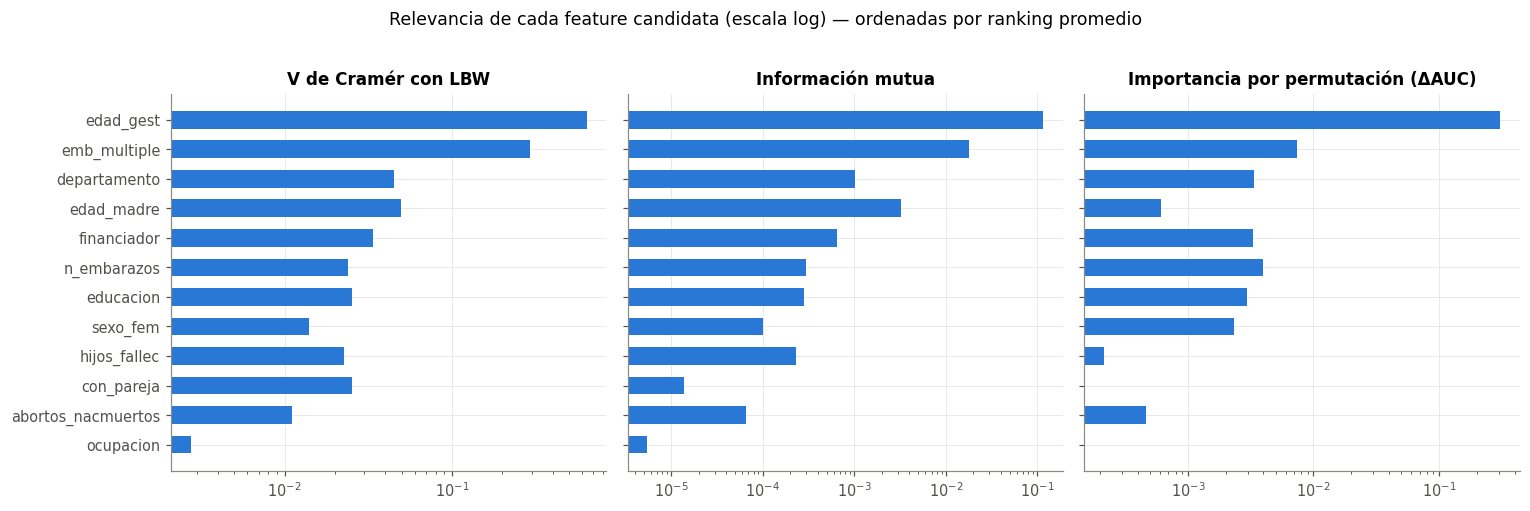

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
order = rank.index[::-1]
for ax, c, t in zip(axs, ["Cramér_V", "Info_mutua", "Permutación_ΔAUC"],
                    ["V de Cramér con LBW", "Información mutua", "Importancia por permutación (ΔAUC)"]):
    ax.barh(order, rank.loc[order, c], color=SEQ, height=0.6); ax.set_title(t); ax.set_xscale("log")
fig.suptitle("Relevancia de cada feature candidata (escala log) — ordenadas por ranking promedio", y=1.02)
savefig("10_relevancia")

In [ ]:
# ¿Cuánto rinden las variables sin la edad gestacional? (escenario "predicción antes del parto")
X2 = X.drop(columns="edad_gest")
rf2 = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=20, class_weight="balanced",
                             n_jobs=-1, random_state=SEED).fit(X2.iloc[:n_tr], y[:n_tr])
print("AUC sin edad gestacional:", round(roc_auc_score(y[n_tr:], rf2.predict_proba(X2.iloc[n_tr:])[:, 1]), 3))

AUC sin edad gestacional: 0.646


## 9. Conclusiones y dataset final

In [ ]:
# Se descartan las 2 últimas del ranking (con_pareja, ocupacion): importancia ≈ 0 en los 3 métodos
FINAL = ["edad_gest", "emb_multiple", "departamento", "edad_madre", "financiador", "n_embarazos",
         "educacion", "sexo_fem", "hijos_fallec", "abortos_nacmuertos"]
final = df[FINAL + ["anio", "peso", "LBW"]].copy()
final = final.dropna(subset=["edad_gest"])        # la variable más importante; sin ella el registro no sirve
print("Dataset final:", final.shape, "| % LBW:", round(final.LBW.mean()*100, 2))
print("Faltantes restantes (%):"); print(final.isna().mean().mul(100).round(2)[lambda s: s > 0])
final.to_csv("cnv_lbw_features_reducidas.csv.gz", index=False, compression="gzip")
final.head()

Dataset final: (4871294, 13) | % LBW: 6.37
Faltantes restantes (%):
emb_multiple          0.17
departamento          0.18
financiador           0.79
n_embarazos           1.02
educacion             0.05
abortos_nacmuertos    8.56
dtype: float64


,edad_gest,emb_multiple,departamento,edad_madre,financiador,n_embarazos,educacion,sexo_fem,hijos_fallec,abortos_nacmuertos,anio,peso,LBW
0,40.0,0.0,15,34.0,SIS,3.0,4.0,0.0,0,1.0,2021,3620.0,0
1,41.0,0.0,13,43.0,ESSALUD,5.0,4.0,0.0,0,0.0,2021,3850.0,0
2,37.0,0.0,21,27.0,SIS,3.0,7.0,1.0,1,0.0,2021,3005.0,0
3,37.0,0.0,15,35.0,PRIVADO,1.0,7.0,0.0,0,0.0,2021,3055.0,0
4,38.0,0.0,14,33.0,ESSALUD,3.0,7.0,1.0,0,0.0,2021,3500.0,0


### Resumen
| | |
|---|---|
| Registros | 4.87 M nacimientos (2015–2025); ≈ 4.86 M después de limpiar el target y la edad gestacional |
| Target | `peso` (regresión) y `LBW` < 2500 g (clasificación) — **6.4 % LBW, desbalance ≈ 1:14.5** |
| Features | **22 columnas originales → 10 features finales** |
| Eliminadas | fecha, talla del RN, cesárea, quién atiende, lugar del parto, IPRESS (leakage, IDs o casi constantes); hijos vivos (redundante); país de la madre (casi constante); **estado civil y ocupación** (relevancia ≈ 0 en los 3 métodos, registro poco confiable) |
| Top predictores | 1) edad gestacional, 2) embarazo múltiple, 3) departamento, 4) edad materna (U), 5) financiador, 6) n° de embarazos, 7) educación, 8) sexo, 9–10) antecedentes obstétricos |
| Rendimiento orientativo (RF, muestra) | AUC **0.90 con** edad gestacional · AUC **0.65 sin** ella |

### Recomendaciones para el modelado
1. **Clasificación (LBW)** como tarea principal, igual que ambos papers. La regresión del peso es un complemento, y su MAE se puede comparar con los 294 g de Khan.
2. Balancear las clases con `class_weight="balanced"` (Almeida) o SMOTE **solo en el train** (Khan). Reportar recall, F1, AUC-ROC y AUC-PR de la clase LBW.
3. Entrenar **dos escenarios**: con edad gestacional (clasificación al nacer, AUC ≈ 0.90) y **sin** ella (riesgo antes del parto, AUC ≈ 0.65). La caída muestra que, sin las variables clínicas (diabetes, hipertensión, controles prenatales), el CNV predice poco antes del parto. Es un hallazgo honesto que vale la pena discutir.

4. Split **temporal** (train 2015–2023, test 2024–2025; **2025 es parcial, corte al 30/11**) o 80/20 estratificado.



 Con 4.8 M filas se puede entrenar con una muestra estratificada de 300–500 k sin perder rendimiento.
5. Imputar los faltantes que quedan (`abortos_nacmuertos` 8.6 %, el resto < 1.1 %) con la mediana o la moda, aplicar one-hot a `departamento` y `financiador`, y escalar las numéricas para LR, SVM y MLP.

**Limitaciones del CNV frente a Khan et al.:** no incluye diabetes, hipertensión, IMC, talla de la madre, controles prenatales ni tabaquismo.
Por eso es de esperar un rendimiento cercano al de Almeida (registro poblacional similar, AUC ≈ 0.85) y no al 90 % de accuracy de Khan.


**Limitaciones de medición del propio CNV:**
- *Heaping* en 2500 g, justo en el umbral de la clase: parte de los recién nacidos registrados con 2500 g
  podrían ser LBW redondeados hacia arriba (ruido en la etiqueta; la prevalencia pasaría de ≈ 6.4 % a ≈ 6.7 % con
  umbral `<= 2500`).
- `Hijos_fallec_madre` usa `-1` tanto para *ninguno* como para *ignorado*, contra lo que indica el diccionario
  oficial (contaminación estimada ≈ 1 %).

